# **SECTION 1 - Environment Setup**

In [2]:
!pip install git+https://github.com/openai/whisper.git --quiet
!pip install torchaudio librosa xgboost scikit-learn sentence-transformers --quiet


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# **SECTION 2 - Imports, Seeds & Device Setup**

In [3]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
import whisper
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# **SECTION 3 - Mount Google Drive**

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **SECTION 4 - Dataset Structure Verification**

In [7]:
# List main dataset folder
!ls "/content/drive/MyDrive/dataset/"

# Check training audio files
!ls "/content/drive/MyDrive/dataset/audios/train/" | head -n 10

# Check testing audio files
!ls "/content/drive/MyDrive/dataset/audios/test/" | head -n 10


audios	csvs
audio_100.wav
audio_101.wav
audio_102_2.wav
audio_10_2.wav
audio_102.wav
audio_103.wav
audio_104.wav
audio_105.wav
audio_106.wav
audio_107.wav
audio_100.wav
audio_10_1.wav
audio_101.wav
audio_102_1.wav
audio_102.wav
audio_103.wav
audio_104.wav
audio_105.wav
audio_106_1.wav
audio_106.wav


# **SECTION 5 - Configuration**
### All dataset paths and audio parameters are stored in a central configuration dictionary for clarity and maintainability.

In [6]:
CONFIG = {
    "train_csv": "/content/drive/MyDrive/dataset/csvs/train.csv",
    "test_csv": "/content/drive/MyDrive/dataset/csvs/test.csv",
    "audios_train": "/content/drive/MyDrive/dataset/audios/train",
    "audios_test": "/content/drive/MyDrive/dataset/audios/test",
    "sample_submission": "/content/drive/MyDrive/dataset/csvs/sample_submission.csv",
    "output_submission": "/content/drive/MyDrive/dataset/submission.csv",
    "target_sample_rate": 16000,
    "max_audio_length": 10  # seconds
}

CONFIG["max_audio_length_samples"] = CONFIG["target_sample_rate"] * CONFIG["max_audio_length"]


# **SECTION 6 - Load Metadata (CSV Files)**
### We load training labels and test filenames provided by the competition.

In [8]:
import pandas as pd

# Load train and test CSVs
train_df = pd.read_csv(CONFIG["train_csv"])
test_df = pd.read_csv(CONFIG["test_csv"])

# Quick look at training data
print("Number of training samples:", len(train_df))
print(train_df.head())

print("Number of test samples:", len(test_df))
print(test_df.head())


Number of training samples: 409
    filename  label
0  audio_173    3.0
1  audio_138    3.0
2  audio_127    2.0
3   audio_95    2.0
4   audio_73    3.5
Number of test samples: 197
    filename
0  audio_141
1  audio_114
2   audio_17
3   audio_76
4  audio_156


# **SECTION 7 - Exploratory Data Analysis**

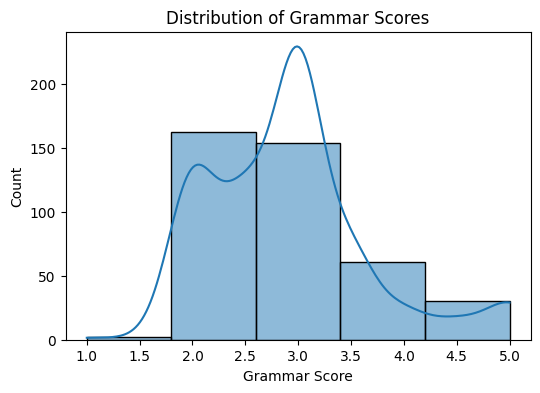

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(train_df['label'], bins=5, kde=True)
plt.title("Distribution of Grammar Scores")
plt.xlabel("Grammar Score")
plt.ylabel("Count")
plt.show()


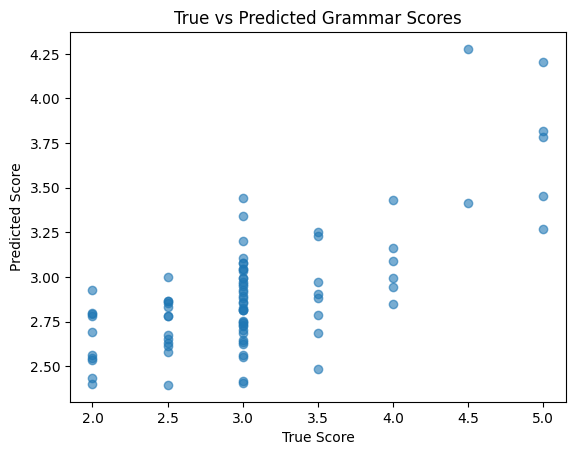

In [31]:
plt.scatter(y_val, val_preds, alpha=0.6)
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("True vs Predicted Grammar Scores")
plt.show()


# **SECTION 8 - Audio Path Resolution**
### The dataset CSV files do not include audio extensions, so we programmatically append .wav to resolve full audio paths.

In [ ]:
train_df['file_path'] = train_df['filename'].apply(
    lambda x: os.path.join(CONFIG["audios_train"], x + ".wav")
)

test_df['file_path'] = test_df['filename'].apply(
    lambda x: os.path.join(CONFIG["audios_test"], x + ".wav")
)

print(train_df[['filename', 'file_path']].head())
print(os.path.exists(train_df['file_path'].iloc[0]))


In [12]:
# Check if any filenames are missing ".wav"
missing_ext = train_df['filename'][~train_df['filename'].str.endswith('.wav')]
print("Files missing .wav extension:\n", missing_ext)


0      audio_173
1      audio_138
2      audio_127
3       audio_95
4       audio_73
5       audio_34
6    audio_120_2
7      audio_224
8      audio_342
9      audio_228
Name: filename, dtype: object
Files missing .wav extension:
 0      audio_173
1      audio_138
2      audio_127
3       audio_95
4       audio_73
         ...    
404     audio_72
405    audio_107
406    audio_271
407    audio_349
408    audio_103
Name: filename, Length: 409, dtype: object


In [14]:
import os

# Print first 5 full paths
print(train_df['file_path'].head())

# Check if the first file exists
print(os.path.exists(train_df['file_path'].iloc[0]))  # Should print True


0    /content/drive/MyDrive/dataset/audios/train/au...
1    /content/drive/MyDrive/dataset/audios/train/au...
2    /content/drive/MyDrive/dataset/audios/train/au...
3    /content/drive/MyDrive/dataset/audios/train/au...
4    /content/drive/MyDrive/dataset/audios/train/au...
Name: file_path, dtype: object
True


# **SECTION 9 - Load Models for Feature Extraction**
### Whisper is used both for deep acoustic representations and automatic speech transcription. SentenceTransformer encodes the transcript into a semantic embedding.

In [15]:
import torch
import whisper
from sentence_transformers import SentenceTransformer

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load Whisper model (for acoustic features and transcription)
print("Loading Whisper model (base)...")
whisper_model = whisper.load_model("base").to(device)

# Load SentenceTransformer model (for text embeddings)
print("Loading SentenceTransformer model (all-mpnet-base-v2)...")
text_encoder = SentenceTransformer("all-mpnet-base-v2")


Using device: cuda
Loading Whisper model (base)...


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 191MiB/s]


Loading SentenceTransformer model (all-mpnet-base-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# **SECTION 10 - Feature Extraction Functions**
### We extract a hybrid feature set combining deep acoustic features, handcrafted acoustic statistics, linguistic embeddings, and utterance duration.

In [16]:
import librosa
import numpy as np
from tqdm import tqdm

# 1. Deep acoustic features (Whisper encoder)
def extract_acoustic_features(audio_path, whisper_model):
    audio = whisper.load_audio(audio_path)
    audio = whisper.pad_or_trim(audio)
    mel = whisper.log_mel_spectrogram(audio).to(device)
    with torch.no_grad():
        encoded = whisper_model.encoder(mel.unsqueeze(0))
    acoustic_feature = encoded.squeeze(0).mean(dim=0).cpu().numpy()
    return acoustic_feature

# 2. Handcrafted acoustic features
def extract_handcrafted_features(audio_path, sr=16000):
    try:
        y, _ = librosa.load(audio_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        rms = librosa.feature.rms(y=y)[0]
        handcrafted = np.concatenate([mfcc_mean, mfcc_std, [np.mean(zcr), np.std(zcr)], [np.mean(rms), np.std(rms)]])
    except:
        handcrafted = np.zeros(30)
    return handcrafted

# 3. Text embeddings from transcription
def extract_text_features(audio_path, whisper_model, text_encoder):
    try:
        result = whisper_model.transcribe(audio_path, fp16=False)
        transcript = result['text']
        text_embed = text_encoder.encode(transcript)
    except:
        text_embed = np.zeros(768)
    return text_embed

# 4. Duration
def compute_duration(audio_path, sr=16000):
    try:
        y, _ = librosa.load(audio_path, sr=sr)
        duration = len(y) / sr
    except:
        duration = 0.0
    return duration


In [17]:
def extract_hybrid_features(df, audio_folder, whisper_model, text_encoder):
    combined_features = []
    for file in tqdm(df['filename'], desc="Extracting hybrid features"):
        file_path = os.path.join(audio_folder, file + ".wav")  # Append .wav since CSV is missing extension
        acoustic_feat = extract_acoustic_features(file_path, whisper_model)
        handcrafted_feat = extract_handcrafted_features(file_path)
        text_feat = extract_text_features(file_path, whisper_model, text_encoder)
        duration = compute_duration(file_path)
        features = np.concatenate([acoustic_feat, handcrafted_feat, text_feat, [duration]])
        combined_features.append(features)
    combined_features = np.array(combined_features)
    return combined_features


# **SECTION 11 - Feature Extraction (Main Execution)**
### Feature extraction is performed once and reused for all downstream modeling.

In [18]:
X_test = extract_hybrid_features(train_df.head(3), CONFIG["audios_train"], whisper_model, text_encoder)
print("Shape of extracted features for 3 samples:", X_test.shape)


Extracting hybrid features: 100%|██████████| 3/3 [00:22<00:00,  7.44s/it]

Shape of extracted features for 3 samples: (3, 1311)


In [19]:
# Training set
print("Extracting features for full training data...")
X_train_features = extract_hybrid_features(train_df, CONFIG["audios_train"], whisper_model, text_encoder)
y_train = train_df['label'].values

# Test set
print("Extracting features for test data...")
X_test_features = extract_hybrid_features(test_df, CONFIG["audios_test"], whisper_model, text_encoder)

# Quick sanity check
print("Training features shape:", X_train_features.shape)  # Should be (409, 1311)
print("Test features shape:", X_test_features.shape)       # Should be (197, 1311)


Extracting features for full training data...


Extracting hybrid features: 100%|██████████| 409/409 [14:15<00:00,  2.09s/it]


Extracting features for test data...


Extracting hybrid features: 100%|██████████| 197/197 [07:49<00:00,  2.38s/it]

Training features shape: (409, 1311)
Test features shape: (197, 1311)


# **SECTION 12 - Train/Validation Split**

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_features,
    y_train,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_val.shape)


(327, 1311) (82, 1311)


In [30]:
from scipy.stats import pearsonr

pearson = pearsonr(y_val, val_preds)[0]
print("Validation Pearson:", pearson)


Validation Pearson: 0.7181089317875158


# **SECTION 13 - Feature Scaling**
### Standardization is applied to stabilize training of tree-based and neural models.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_features)


# **SECTION 14 - Model Training & Evaluation**

In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_scaled,
    y_train_split,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# Validation RMSE
val_preds = xgb_model.predict(X_val_scaled)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print("Validation RMSE:", rmse)


Validation RMSE: 0.5723660790937549


# **SECTION 15 - Final Training on Full Data**

In [23]:
# Scale full training data
X_full_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# Retrain model on full data
final_model = XGBRegressor(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full_scaled, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=-1, num_parallel_tree=None, ...)

# **SECTION 16 - Inference & Submission**

In [24]:
test_predictions = final_model.predict(X_test_scaled)


In [27]:
submission = test_df[['filename']].copy()
submission['label'] = test_predictions

submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")


submission.csv saved successfully
